### **ClinTox_Morgan_model**

### Predict toxicity for any list of compounds, drugs

### **`ClinTox_Morgan_model` is a pre‑trained DeepPurpose model** that predicts clinical toxicity of molecules
- It uses `drug_encoding="Morgan"` to convert drugs to **Morgan fingerprints** (bit vectors), using **any valid, RDKit‑parsable SMILES string** will work  
- It is part of the **DPP DeepPurpose** library’s collection of pre‑trained models for `drug_property_prediction`. 
- A **neural‑network model** (often a simple feed‑forward or convolutional net) on top of the Morgan bits.  
- The “Morgan” part means it **does not use sequence‑based features** (like SMILES‑LSTM), only **Morgan‑fingerprint vectors**
- Trained to predict **clinical‑toxicity status** (usually a binary or multi‑class toxicity label) for small molecules
- It is typically trained on **Tox21 / ClinTox‑style clinical‑toxicity datasets**, where each molecule is labeled as safe or toxic based on clinical or regulatory endpoints.

### What you can do with it
- Predict **clinical‑toxicity probability** for any SMILES string that RDKit can parse.  
- Use it as a **toxicity filter** in virtual screening or drug‑discovery pipelines.  
- Combine it with other models (e.g., solubility, potency) to build **multi‑objective scoring** for compound prioritization.  

**In short: `ClinTox_Morgan_model` is a **plug‑and‑play clinical‑toxicity predictor** that takes SMILES, converts them to Morgan fingerprints, and returns a toxicity score, all wrapped in DeepPurpose**
- once you have **ClinTox_Morgan_model**, you can turn it into a general **toxicity‑score‑engine** over SMILES input, useful for screening, ranking, visualization, and as a safety‑guard component in more complex drug‑design pipelines.
**You can feed any valid SMILES list (drug candidates, fragments, metabolites, etc.) into the same model pipeline:**
    Batch‑predict clinical‑toxicity probability for hundreds or thousands of molecules.
    Rank them by toxicity_prob (ascending = safest molecules first) for prioritization.
    Export a CSV with Name, SMILES, Toxicity_Prob, Toxicity_Class for downstream chem‑info workflows

In [1]:
#  1. SILENCE EVERYTHING FIRST (BEFORE ANY IMPORTS!)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'    # 0=all, 1=filter INFO, 2=filter WARNINGS, 3=ERROR ONLY
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN
os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'   # RDKit silence
from pathlib import Path
# 2. NOW import everything
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Kill RDKit

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")
# Suppress only this torch.load / weights_only warning
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

import logging
# Silence DeepPurpose / compound property logging
logging.getLogger("DeepPurpose").setLevel(logging.ERROR)
logging.getLogger("CompoundPred").setLevel(logging.ERROR)
# or globally:
logging.getLogger().setLevel(logging.ERROR)

from DeepPurpose import utils, dataset, DTI as models
from DeepPurpose import utils, dataset, CompoundPred  # This DeepPurpose is the local directory
import tensorflow as tf
from DeepPurpose import DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import *

from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np

**Before passing SMILES to DeepPurpose or any RDKit‑backed model, filter out invalid ones:**
- If one of your SMILES strings describes a carbon atom with 5 bonds, which is chemically invalid in normal organic chemistry (carbon is limited to valence ≤ 4), RDKit rejects such SMILES during parsing

```
valid_drugs = {}
 for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_drugs[name] = smi
```     
DeepPurpose  `ClinTox_Morgan_model **SMILES format requirement** is fairly standard and simple:  
-  `ClinTox_Morgan_model` is trained on fingerprints, so as long as your SMILES can be turned into a valid fingerprint, they are acceptable.
- Prefer **canonical SMILES** from sources like **PubChem**, **ChEMBL**, or **DrugBank**; they are less likely to parse‑error.  
- Validate with **RDKit‑parsable SMILES strings** (no syntax errors, no extra parentheses, correct valences)

```
  from rdkit import Chem
  mol = Chem.MolFromSmiles("your_smiles")
  if mol is None:
      print("Invalid SMILES")
```
 
  ```

In [3]:
from rdkit import Chem

drugs = {
    "Remdesivir": "CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4",
    "GS-441524": "OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N",
    "HydroxyChloroquine": "CCN(CC)CCCC(C)NC1=CC2=C(C=C1)NC(=NC2=O)N",
    "Oseltamivir": "CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@H](N)C1"
    #"Ivermectin": "CC1=C(C(CC2C3=C(C(C4=C5C(=C(C)C(C(C5(C(C4(C3CC2)(C))C)O)O)C(C1)(C)C)=O)C)C(=C)C)C"
    #"HydroxyChloroquine":  "CCN(CC)CCCC(C)NC1=CC2=C(C=C1)NC(=NC2=O)N" 
}

for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Invalid SMILES for {name}: {smi}")

In [4]:
# Load DeepPurpose ClinTox pre‑trained model (clinical toxicity yes/no)
model_type = "Morgan"   # or "MPNN", "CNN" – Morgan is simple and fast
task = "ClinTox"
model_name = task + "_" + model_type + "_model"

print("Loading pre-trained toxicity model:", model_name)
model = CompoundPred.model_pretrained(model=model_name)

Loading pre-trained toxicity model: ClinTox_Morgan_model
Dataset already downloaded in the local system...


In [5]:
# turn drugs dict into lists
smiles_list = list(drugs.values())
names_list = list(drugs.keys())

# preprocess for DeepPurpose
X = utils.data_process(
    X_drug=smiles_list,
    y=[0] * len(smiles_list),           # dummy labels
    drug_encoding=model_type,
    split_method="no_split"
)


# predict toxicity probabilities (1 = toxic, 0 = non‑toxic)
probs = np.array(model.predict(X))   # force to ndarray
tox_df = pd.DataFrame({
    "Drug": names_list,
    "SMILES": smiles_list,
    "Toxicity_Prob": probs.ravel(),
    "Toxicity_Class": ["Toxic" if p >= 0.5 else "Non‑toxic" for p in probs]
})


# sort by predicted toxicity (descending: most toxic first)
tox_df = tox_df.sort_values("Toxicity_Prob", ascending=False).reset_index(drop=True)

print("Predicted clinical toxicity:")
print(tox_df)

Drug Property Prediction Mode...
in total: 4 drugs
encoding drug...
unique drugs: 4
do not do train/test split on the data for already splitted data
predicting...
Predicted clinical toxicity:
                 Drug                                             SMILES  \
0  HydroxyChloroquine           CCN(CC)CCCC(C)NC1=CC2=C(C=C1)NC(=NC2=O)N   
1           GS-441524  OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1...   
2         Oseltamivir  CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@...   
3          Remdesivir  CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=...   

   Toxicity_Prob Toxicity_Class  
0       0.059898      Non‑toxic  
1       0.008306      Non‑toxic  
2       0.000690      Non‑toxic  
3       0.000009      Non‑toxic  


In [6]:
tox_df.to_csv("toxicity_predictions_ClinTox.csv", index=False)
print("Saved predictions to 'toxicity_predictions_ClinTox.csv'")

Saved predictions to 'toxicity_predictions_ClinTox.csv'


In [7]:
top_k = 10

print("### Top {} Drugs by Predicted Clinical Toxicity".format(top_k))
print()
print("| Rank | Drug | Class | Toxicity (prob) | SMILES |")
print("|------|------|-------|-----------------|--------|")

for idx, row in tox_df.head(top_k).iterrows():
    print(f"| {idx+1:2} | {row['Drug']} | {row['Toxicity_Class']} | {row['Toxicity_Prob']:.3f} | {row['SMILES'][:50]}... |")

### Top 10 Drugs by Predicted Clinical Toxicity

| Rank | Drug | Class | Toxicity (prob) | SMILES |
|------|------|-------|-----------------|--------|
|  1 | HydroxyChloroquine | Non‑toxic | 0.060 | CCN(CC)CCCC(C)NC1=CC2=C(C=C1)NC(=NC2=O)N... |
|  2 | GS-441524 | Non‑toxic | 0.008 | OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc... |
|  3 | Oseltamivir | Non‑toxic | 0.001 | CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@H](N... |
|  4 | Remdesivir | Non‑toxic | 0.000 | CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C... |


In [8]:
def get_morgan_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [9]:
X_fp = []
valid_smiles = []

for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Skipping invalid SMILES for {name}: {smi}")
        continue
    fp = get_morgan_fingerprint(smi, radius=2, n_bits=1024)
    X_fp.append(fp)
    valid_smiles.append(smi)

X_fp = np.array(X_fp)   # now all elements are arrays of same shape

In [10]:

drugs = {
    "Remdesivir": "CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4",
    "GS-441524": "OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N",
    "HydroxyChloroquine": "CCN(CC)CCCC(C)NC1=CC2=C(C=C1)NC(=NC2=O)N",
    "Oseltamivir": "CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@H](N)C1",
    "Ivermectin": "CC1=C(C(CC2C3=C(C(C4=C5C(=C(C)C(C(C5(C(C4(C3CC2)(C))C)O)O)C(C1)(C)C)=O)CH3)C(=C)C)C",  # corrected parentheses
}

def get_morgan_fingerprint(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# build valid subset + fingerprints
X_fp = []
names_list = []
smiles_list = []

for name, smi in drugs.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Skipping invalid SMILES for {name}")
        continue
    fp = get_morgan_fingerprint(smi, radius=2, n_bits=1024)
    if fp is not None:
        X_fp.append(fp)
        names_list.append(name)
        smiles_list.append(smi)

X_fp = np.array(X_fp)   # now shape (n_valid, 1024)
print("Fingerprint shape:", X_fp.shape)



Skipping invalid SMILES for Ivermectin
Fingerprint shape: (4, 1024)


In [11]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Option 1: PCA (fast, linear)
# emb = PCA(n_components=2).fit_transform(X_fp)

# Option 2: t-SNE (nonlinear, more "contour‑map"‑like)
emb = TSNE(n_components=2, random_state=7, perplexity=2).fit_transform(X_fp)

tox_df["x"] = emb[:, 0]
tox_df["y"] = emb[:, 1]

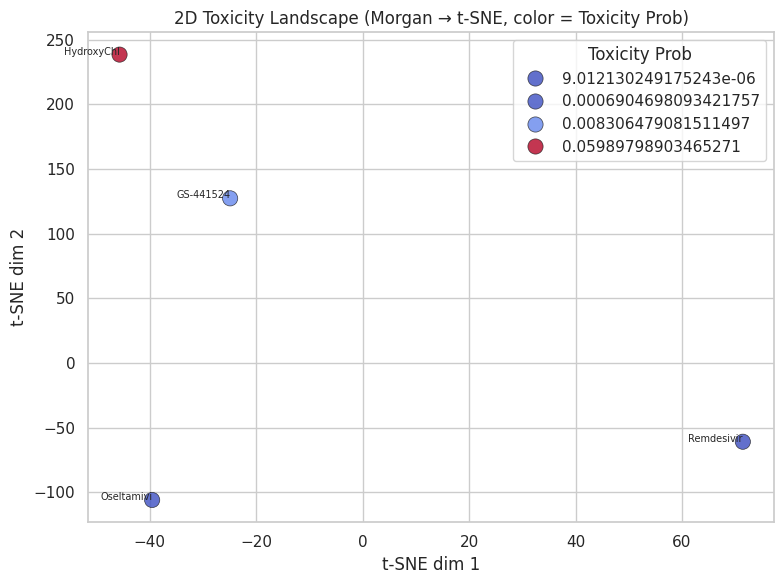

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tox_df,
    x="x", y="y",
    hue="Toxicity_Prob",
    palette="coolwarm",
    s=120,
    alpha=0.8,
    edgecolor="k",
    linewidth=0.5
)

for idx, row in tox_df.iterrows():
    plt.text(row["x"], row["y"], row["Drug"][:10], fontsize=7, ha="right")

plt.title("2D Toxicity Landscape (Morgan → t‑SNE, color = Toxicity Prob)")
plt.xlabel("t‑SNE dim 1")
plt.ylabel("t‑SNE dim 2")
plt.legend(title="Toxicity Prob")
plt.tight_layout()
plt.show()

In [13]:
tox_df[["Drug", "SMILES", "x", "y", "Toxicity_Prob", "Toxicity_Class"]].to_csv(
    "toxicity_landscape_data.csv", index=False
)